In [1]:
import json
import numpy as np
from openai import OpenAI, AsyncOpenAI
import openai
from collections import defaultdict
import pytrec_eval
from string import Template
import pytrec_eval
import random
print(openai.__version__)
apikey = ''
client = AsyncOpenAI(api_key=apikey)
random.seed(0)

1.90.0


In [2]:
import sys
sys.path.append('./..')
from prompts.all_prompts import *
from order_by.sorting import *
from order_by.utils import *
from order_by.optimizer import *
from order_by.pointwise import *

In [3]:
from dataclasses import dataclass
from tqdm import tqdm
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

@dataclass
class Passage:
    passageid: str
    text: str

In [4]:
class SafeDict(dict):
    def __missing__(self, k):  # leave untouched
        return '{' + k + '}'
def tokens2price(model, in_tokens, out_tokens):
    """
    Calculate the API cost given the model and number of input/output tokens.

    Pricing (as of Sep 2025):
    - gpt-4o:       $2.50 per 1M input tokens, $10.00 per 1M output tokens
    - gpt-4o-mini:  $0.150 per 1M input tokens, $0.600 per 1M output tokens
    """
    if model == 'gpt-4o':
        input_rate = 2.50 / 1_000_000
        output_rate = 10.00 / 1_000_000
    elif model == 'gpt-4o-mini':
        input_rate = 0.150 / 1_000_000
        output_rate = 0.600 / 1_000_000
    else:
        raise ValueError(f"Unknown model: {model}")

    total_cost = in_tokens * input_rate + out_tokens * output_rate
    return round(total_cost, 6) 
        

In [5]:
def load_run_file(path, sample_ratio = None):
    map_key_2_criteria = {'irony':'irony', 'hate': 'hateful', 'sentiment':'positive', 'offensive':'offensive'}
    random.seed(0)
    first_stage_rankings = []
    id_to_list = defaultdict(list)
    label_by_id = defaultdict(dict)
    
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
        
    if sample_ratio is not None:
        for k in data.keys():
            texts = data[k]["text"]
            labels = data[k]["label"]

            n = len(texts)
            sample_size = max(1, int(n * sample_ratio))

            indices = random.sample(range(n), sample_size)
            data[k]["text"] = [texts[i] for i in indices]
            data[k]["label"] = [labels[i] for i in indices]
            
    print(data.keys())
    i = 0
    for key, d in data.items():
        print(key)
        criteria = map_key_2_criteria[key]
        text_id = 0
        for text, label in zip(d['text'], d['label']):
            id_to_list[str(i)].append(Passage(passageid=str(text_id), text=text))
            label_by_id[str(i)][str(text_id)] = int(label)            
            text_id += 1
        i += 1
            
    for index, key in enumerate(data.keys()):
        criteria = map_key_2_criteria[key]
        passages = id_to_list[str(index)]
        first_stage_rankings.append(( criteria, passages))
        
    return first_stage_rankings, label_by_id

In [6]:
tweetEval_file = '../data/tweetEval.json'
first_stage_candidates, gold = load_run_file(tweetEval_file)

evaluator = pytrec_eval.RelevanceEvaluator(gold, {'ndcg_cut.10'})

dict_keys(['irony', 'hate', 'sentiment', 'offensive'])
irony
hate
sentiment
offensive


In [7]:
print(len(first_stage_candidates))
print(len(first_stage_candidates[0]))
arr = [ len(c) for _, c in first_stage_candidates]
print(arr)

4
2
[100, 100, 100, 100]


# Optimizer

In [8]:

for modelname, budget in [("gpt-4o-mini", 0.3), ("gpt-4o-mini", 100), ("gpt-4o", 2), ("gpt-4o", 500)]:
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    total_budget = budget
    for i, (criteria, ranking) in enumerate(tqdm(first_stage_candidates)):
        curr_budget = 1.0 * budget / (len(first_stage_candidates)-i)
        
        passage_list = []
        for r in ranking:
            passage_list.append( (r.passageid, r.text) ) 
        batch_space = None
        if modelname == "gpt-4o-mini":
            batch_space = [4,6]

        optimizer = OrderByOptimizer(client, passage_list[:], 
                                    membership_inference_prompt.format_map(SafeDict(description="tweets")),
                                    tweetEval_pointwise_prompt_template.format_map(SafeDict(criteria=criteria)),
                                    tweetEval_external_pointwise_prompt_template.format_map(SafeDict(criteria=criteria)),
                                    tweetEval_pairwise_comparison_prompt_template.format_map(SafeDict(criteria=criteria)),
                                    tweetEval_external_comparison_prompt_template.format_map(SafeDict(criteria=criteria)),
                                    curr_budget, modelname, isPassage=True, batch_space=batch_space)

        sorted_data, num_api_calls, in_tokens, out_tokens = await optimizer.physical_order_by_impl()
        if type(sorted_data[0]) == tuple:
            run[str(i)] = {
                str(text_id): float(1.0 * i / (len(sorted_data) - 1))
                for (text_id, text), i in zip( sorted_data, range(len(sorted_data)) )
            }
        else:
            run[str(i)] = {
            str(text_id): float(1.0 * i / (len(sorted_data) - 1))
            for text_id, i in zip( sorted_data, range(len(sorted_data)) )
        }
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
        
        budget -= tokens2price(modelname, in_tokens, out_tokens)

    metrics = evaluator.evaluate(run)
    mean_ndcg = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
    print(f"{modelname}, optimizer {total_budget} output nDCG@10:", mean_ndcg)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")



  0%|                                                     | 0/4 [00:00<?, ?it/s]

ext_bubble_4 estimated cost 0.148325
ext_bubble_6 estimated cost 0.09155555555555556
ext_merge_4 estimated cost 0.01918911104523406
from window m=4: 0.7 from window 2m: 0.3
from window m=4: 0.8 from window 2m: 0.6
from window m=4: 0.6 from window 2m: 0.9
Final memory size for external pointwise: m = 4 (agreement = 0.62)
point estimated cost 0.009755
ext_point estimated cost 0.008664999999999999
quick estimated cost 0.04641706970728214
ext_merge_4 estimated cost 0.026665334218053813
ext_bubble_4 estimated cost 0.17639045454545457
------------------
decided to use ext_merge_4
------------------
ext_bubble_4 estimated cost 0.167025
ext_bubble_6 estimated cost 0.09727777777777778
ext_merge_4 estimated cost 0.020458978687933376
from window m=2: 0.9 from window 2m: 0.4
from window m=2: 0.8 from window 2m: 0.5
Final memory size for external pointwise: m = 2 (agreement = 0.50)
point estimated cost 0.010485
ext_point estimated cost 0.00896
quick estimated cost 0.05482579205531436
ext_merge_4 es

100%|█████████████████████████████████████████████| 4/4 [00:00<00:00, 10.52it/s]


ext_bubble_4 estimated cost 0.1428
ext_bubble_6 estimated cost 0.08602407407407407
ext_merge_4 estimated cost 0.01862472542625659
from window m=4: 0.2 from window 2m: 0.4
from window m=4: 0.8 from window 2m: 0.6
from window m=4: 0.7 from window 2m: 0.4
Final memory size for external pointwise: m = 4 (agreement = 0.62)
point estimated cost 0.009215
ext_point estimated cost 0.00819
quick estimated cost 0.05775424106317569
ext_merge_4 estimated cost 0.02262178560773409
ext_bubble_6 estimated cost 0.08401217391304348
ext_bubble_4 estimated cost 0.16672363636363638
------------------
decided to use point
------------------
ext_bubble_4 estimated cost 0.17595
ext_merge_4 estimated cost 0.021869942735377054
from window m=2: 0.4 from window 2m: 0.1
from window m=2: 0.5 from window 2m: 0.7
Final memory size for external pointwise: m = 2 (agreement = 0.50)
point estimated cost 0.0095
ext_point estimated cost 0.00848
quick estimated cost 0.06807683166044012
ext_merge_4 estimated cost 0.0315158935

  0%|                                                     | 0/4 [00:00<?, ?it/s]

...

ext_bubble_4 estimated cost 2.471375
ext_merge_4 estimated cost 0.29559696793945117
from window m=2: 0.6 from window 2m: 0.2
from window m=4: 0.9 from window 2m: 0.7
from window m=4: 0.7 from window 2m: 0.9
from window m=8: 0.7 from window 2m: 0.8
from window m=8: 0.2 from window 2m: 0.0
from window m=8: 0.8 from window 2m: 0.7
Final memory size for external pointwise: m = 16
point estimated cost 0.18974
ext_point estimated cost 0.163515
quick estimated cost 0.887527577264426
quick_3 estimated cost 2.570213608559752
ext_merge_4 estimated cost 0.5155524478157649
ext_bubble_4 estimated cost 3.238569545454545
------------------
decided to use ext_merge_4
------------------


 25%|███████████▎                                 | 1/4 [00:00<00:00,  9.99it/s]

ext_bubble_4 estimated cost 2.671125
ext_merge_4 estimated cost 0.3527410118609203
from window m=2: 0.7 from window 2m: 0.9
from window m=2: 0.9 from window 2m: 0.6
from window m=2: 0.8 from window 2m: 0.5
Final memory size for external pointwise: m = 2 (agreement = 0.25)
point estimated cost 0.201015
ext_point estimated cost 0.13286499999999998
quick estimated cost 1.018116418848583
quick_3 estimated cost 2.7489220171090425
ext_merge_4 estimated cost 0.4962946228166162
ext_bubble_4 estimated cost 3.167331818181818
------------------
decided to use point
------------------
ext_bubble_4 estimated cost 2.3447250000000004
ext_merge_4 estimated cost 0.2824750022982249
from window m=2: 0.9 from window 2m: 0.7
from window m=4: 0.7 from window 2m: 0.8
from window m=8: 0.3 from window 2m: 0.5
from window m=8: 0.8 from window 2m: 1.0
from window m=8: 0.2 from window 2m: 0.0
from window m=8: 0.7 from window 2m: 0.5
from window m=8: 0.2 from window 2m: 0.0
from window m=8: 0.2 from window 2m: 0.0

100%|█████████████████████████████████████████████| 4/4 [00:00<00:00,  6.92it/s]

ext_bubble_4 estimated cost 2.921025
ext_merge_4 estimated cost 0.35838486805069497
from window m=2: 0.6 from window 2m: 0.8
from window m=2: 0.2 from window 2m: 0.6
Final memory size for external pointwise: m = 2 (agreement = 0.50)
point estimated cost 0.17962499999999998
ext_point estimated cost 0.12831499999999998
quick estimated cost 1.194322963481708
quick_3 estimated cost 2.5670161419264965
ext_merge_4 estimated cost 0.46724223574247026
ext_bubble_4 estimated cost 3.017994545454546
------------------
decided to use ext_merge_4
------------------
gpt-4o, optimizer 500 output nDCG@10: 0.8739838856013711
tokens: 790998, price: 3.942263


In [ ]:
gpt-4o-mini, optimizer 0.3 output nDCG@10: 0.7823817921962923
tokens: 502104, price: 0.149056
        
gpt-4o-mini, optimizer 100 output nDCG@10: 0.8000397116334714
tokens: 1038748, price: 0.311774
        
gpt-4o, optimizer 2 output nDCG@10: 0.883454489816776
tokens: 267256, price: 1.333713

gpt-4o, optimizer 500 output nDCG@10: 0.8739838856013711
tokens: 790998, price: 3.942263

In [8]:
# for gpt4o
price_est = {'ext_bubbble_4': 3.1256270833333333 + 3.153960416666666 + 2.610385416666667 + 2.9909375000000002,
             'ext_merge_4': 0.44407741786544125 + 0.42878021598440597 + 0.34209999133644914 + 0.3925419560325607,
             'point': 0.18871875 + 0.19983125000000002 + 0.1633625 + 0.17646875 + 0.17646875, 
             'ext_point': 0.18754374999999998 + 0.13901875 + 0.1658625 + 0.18803125,
             'quick': 0.83593206200251 + 0.9751208491782956 + 1.0035337154148791 + 1.1504771284871624,
             'quick_3': 2.4072030127817077 + 2.298835489711304 + 2.447311142117354 + 2.4451518888556776,
            }
print("est", price_est)


true_cost = {'ext_bubbble_4':11.95043,
             'ext_merge_4': 1.916895,
             'point': 0.735815,
             'ext_point': 0.34259,
             'quick': 4.662287,
             'quick_3': 10.37553,
            }
print(true_cost)
for key, true_v in true_cost.items():
    est_v = price_est[key]
    print(key, (abs(true_v - est_v)))

est {'ext_bubbble_4': 11.880910416666666, 'ext_merge_4': 1.607499581218857, 'point': 0.9048499999999999, 'ext_point': 0.68045625, 'quick': 3.9650637550828476, 'quick_3': 9.598501533466044}
{'ext_bubbble_4': 11.95043, 'ext_merge_4': 1.916895, 'point': 0.735815, 'ext_point': 0.34259, 'quick': 4.662287, 'quick_3': 10.37553}
ext_bubbble_4 0.06951958333333508
ext_merge_4 0.30939541878114296
point 0.16903499999999994
ext_point 0.33786625
quick 0.6972232449171525
quick_3 0.777028466533956


# How well does alg on samples reflect the end results

In [43]:
results = {}
for modelname in ["gpt-4o-mini", "gpt-4o"]:
    results[modelname] = defaultdict(list)
    
sample_ratios = [0.1, 0.15, 0.2, 0.25]
for sample_ratio in [0.1, 0.15, 0.2, 0.25]:
    tweetEval_file = './data/tweetEval.json'
    first_stage_candidates, gold = load_run_file(tweetEval_file, sample_ratio)
    evaluator = pytrec_eval.RelevanceEvaluator(gold, {'ndcg_cut.10'})
    
    print('sample ratio', sample_ratio)
    for modelname in ["gpt-4o-mini", "gpt-4o"]:
        
        run = {}
        total_input_tokens = 0
        total_output_tokens = 0

        for i, (criteria, ranking) in enumerate(tqdm(first_stage_candidates)):
            passage_list = []
            for r in ranking:
                passage_list.append( (r.passageid, r.text) ) 

            pointwise_prompt_template = tweetEval_pointwise_prompt_template.format_map(SafeDict(criteria=criteria))

            sorted_data, scores, num_api_calls, in_tokens, out_tokens, confidences =\
                await pointwise_sort(passage_list, client, pointwise_prompt_template,
                                     modelname, float, PointwiseRelevanceKey)
            run[str(i)] = {str(text_id): float(score) for text_id, score in zip(sorted_data, scores)}

            total_input_tokens += in_tokens
            total_output_tokens += out_tokens

        metrics = evaluator.evaluate(run)
        mean_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
        print(f"{modelname}, pointwise Mean nDCG@10:", mean_pointwise)
        results[modelname]['point'].append(mean_pointwise)

        run = {}
        total_input_tokens = 0
        total_output_tokens = 0

        for i, (criteria, ranking) in enumerate(tqdm(first_stage_candidates)):
            print(criteria)
            passage_list = []
            for r in ranking:
                passage_list.append( (r.passageid, r.text) ) 
            external_pointwise_prompt_template = tweetEval_external_pointwise_prompt_template.format_map(SafeDict(criteria=criteria))
            sorted_data, scores, num_api_calls, in_tokens, out_tokens, confidences, _ =\
                await external_pointwise_sort(passage_list, external_values, client, external_pointwise_prompt_template,\
                                              modelname, float, 0.1, isPassage=True)
            run[str(i)] = {str(text_id): float(score) for text_id, score in zip(sorted_data, scores)}
            
            total_input_tokens += in_tokens
            total_output_tokens += out_tokens

        metrics = evaluator.evaluate(run)
        mean_external_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
        print(f"{modelname}, extrernal pointwise Mean nDCG@10:", mean_external_pointwise)
        results[modelname]['ext_point'].append(mean_pointwise)
        
        run = {}
        total_input_tokens = 0
        total_output_tokens = 0

        for i, (criteria, ranking) in enumerate(tqdm(first_stage_candidates)):
            passage_list = []
            for r in ranking:
                passage_list.append( (r.passageid, r.text) ) 

            pairwise_comparison_prompt_template = tweetEval_pairwise_comparison_prompt_template.format_map(SafeDict(criteria=criteria))
            vote = 1
            sorted_data, num_api_calls, in_tokens, out_tokens =\
                await quick_sort(passage_list, client, pairwise_comparison_prompt_template, modelname, True, vote)
            run[str(i)] = {
                str(text_id): float(1.0 * i / (len(sorted_data) - 1))
                for (text_id, text), i in zip( sorted_data, range(len(sorted_data)) )
            }
            total_input_tokens += in_tokens
            total_output_tokens += out_tokens

        metrics = evaluator.evaluate(run)
        mean_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
        print(f"{modelname}, quick_sort Mean nDCG@10:", mean_pointwise)
        results[modelname]['quick'].append(mean_pointwise)


        run = {}
        total_input_tokens = 0
        total_output_tokens = 0
        for i, (criteria, ranking) in enumerate(tqdm(first_stage_candidates)):
            passage_list = []
            for r in ranking:
                passage_list.append( (r.passageid, r.text) ) 

            pairwise_comparison_prompt_template = tweetEval_pairwise_comparison_prompt_template.format_map(SafeDict(criteria=criteria))
            vote = 3

            sorted_data, num_api_calls, in_tokens, out_tokens =\
                await quick_sort(passage_list, client, pairwise_comparison_prompt_template, modelname, True, vote)

            run[str(i)] = {
                str(text_id): float(1.0 * i / (len(sorted_data) - 1))
                for (text_id, text), i in zip( sorted_data, range(len(sorted_data)) )
            }
            total_input_tokens += in_tokens
            total_output_tokens += out_tokens

        metrics = evaluator.evaluate(run)
        mean_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
        print(f"{modelname}, quick_sort with vote={vote} Mean nDCG@10:", mean_pointwise)
        results[modelname]['quick_3'].append(mean_pointwise)

        memory = [4, 8]
        if "mini" in modelname:
            memory = [4]

        for m in memory:
            run = {}
            total_input_tokens = 0
            total_output_tokens = 0
            for i, (criteria, ranking) in enumerate(tqdm(first_stage_candidates)):
                passage_list = []
                for r in ranking:
                    passage_list.append( (r.passageid, r.text) ) 

                external_comparison_prompt_template = tweetEval_external_comparison_prompt_template.format_map(SafeDict(criteria=criteria))
                sorted_data, num_api_calls, in_tokens, out_tokens =\
                    await external_bubble_sort(passage_list, external_comparisons, m, client, external_comparison_prompt_template, modelname, True, False)

                run[str(i)] = {
                    str(text_id): float(1.0 * i / (len(sorted_data) - 1))
                    for (text_id, text), i in zip( sorted_data, range(len(sorted_data)) )
                }
                total_input_tokens += in_tokens
                total_output_tokens += out_tokens

            metrics = evaluator.evaluate(run)
            mean_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
            print(f"{modelname}, external_bubble_sort Mean nDCG@10:", mean_pointwise)
            results[modelname][f'ext_bubble_{m}'].append(mean_pointwise)


            run = {}
            total_input_tokens = 0
            total_output_tokens = 0
            for i, (criteria, ranking) in enumerate(tqdm(first_stage_candidates)):
                passage_list = []
                for r in ranking:
                    passage_list.append( (r.passageid, r.text) ) 

                external_comparison_prompt_template = tweetEval_external_comparison_prompt_template.format_map(SafeDict(criteria=criteria))
                sorted_data, num_api_calls, in_tokens, out_tokens =\
                    await external_merge_sort(passage_list, external_comparisons, m, client, external_comparison_prompt_template, modelname, True, False)

                run[str(i)] = {
                    str(text_id): float(1.0 * i / (len(sorted_data) - 1))
                    for (text_id, text), i in zip( sorted_data, range(len(sorted_data)) )
                }
                total_input_tokens += in_tokens
                total_output_tokens += out_tokens
            metrics = evaluator.evaluate(run)
            mean_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
            print(f"{modelname}, external_merge_sort Mean nDCG@10:", mean_pointwise)
            results[modelname][f'ext_merge_{m}'].append(mean_pointwise)

dict_keys(['irony', 'hate', 'sentiment', 'offensive'])
irony
hate
sentiment
offensive
sample ratio 0.1


100%|████████████████████████████████████████████| 4/4 [00:00<00:00, 737.49it/s]


gpt-4o-mini, pointwise Mean nDCG@10: 0.9384476486844289


100%|████████████████████████████████████████████| 4/4 [00:00<00:00, 387.04it/s]


irony
from window m=2: 0.1 from window 2m: 0.3
from window m=4: 0.3 from window 2m: 0.0
from window m=4: 0.7 from window 2m: 0.0
Final memory size for external pointwise: m = 8
hateful
from window m=2: 0.3 from window 2m: 0.4
from window m=4: 0.6 from window 2m: 0.3
from window m=4: 0.8 from window 2m: 0.6
from window m=4: 0.9 from window 2m: 0.7
from window m=4: 0.6 from window 2m: 0.4
Final memory size for external pointwise: m = 8
positive
from window m=2: 0.1 from window 2m: 0.3
from window m=4: 0.2 from window 2m: 0.4
from window m=4: 0.1 from window 2m: 0.5
Final memory size for external pointwise: m = 8
offensive
from window m=2: 0.8 from window 2m: 0.7
from window m=4: 0.6 from window 2m: 0.3
from window m=4: 0.7 from window 2m: 0.5
Final memory size for external pointwise: m = 8
gpt-4o-mini, extrernal pointwise Mean nDCG@10: 0.9616734614516784


...

gpt-4o, external_merge_sort Mean nDCG@10: 0.8654413664208663


100%|████████████████████████████████████████████| 4/4 [00:00<00:00, 368.33it/s]


gpt-4o, external_bubble_sort Mean nDCG@10: 0.8579091089427665


100%|████████████████████████████████████████████| 4/4 [00:00<00:00, 399.96it/s]

gpt-4o, external_merge_sort Mean nDCG@10: 0.8884715147831798


In [10]:
ratios = [10, 15, 20, 25, 30]

markers = {'pint': 'o', 'ext_point': '^',
           'quick': 's', 'quick_3': 's',
           'ext_bubble': '*', 'ext_merge': 'D'
          } 

linestyles = ['--', '-.', ':']

def get_style(key):
    """Return (marker, linestyle) pair depending on algorithm family."""
    for base in markers.keys():
        if key.startswith(base):
            # Choose line style variant based on numeric suffix (if any)
            idx = 0
            if '_' in key:
                suffix = key.split('_')[-1]
                if suffix.isdigit():
                    idx = int(suffix) % len(linestyles)
            return markers[base], linestyles[idx]
    return 'o', '-'  # default

# Plot for GPT-4o-mini
plt.figure(figsize=(8, 6))
for alg, values in results['gpt-4o-mini'].items():
    m, ls = get_style(alg)
    plt.plot(ratios, values, marker=m, linestyle=ls, label=alg)
plt.title('GPT-4o-mini')
plt.xlabel('Sample Size')
plt.ylabel('nDCG@10')
plt.xticks(ratios, ['10', '15', '20', '25', '100'])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot GPT-4o ---
plt.figure(figsize=(8, 6))
for alg, values in results['gpt-4o'].items():
    if '8' in alg:
        continue
    m, ls = get_style(alg)
    plt.plot(ratios, values, marker=m, linestyle=ls, label=alg)
plt.title('GPT-4o')
plt.xlabel('Sample Size')
plt.ylabel('nDCG@10')
plt.xticks(ratios, ['10', '15', '20', '25', '100'])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'results' is not defined

<Figure size 800x600 with 0 Axes>

# Pointwise experiments

In [14]:
results = {}

for modelname in ["gpt-4o-mini", "gpt-4o"]:
    results[modelname] = {}
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    
    for i, (criteria, ranking) in enumerate(tqdm(first_stage_candidates)):
        passage_list = []
        for r in ranking:
            passage_list.append( (r.passageid, r.text) ) 
            
        pointwise_prompt_template = tweetEval_pointwise_prompt_template.format_map(SafeDict(criteria=criteria))

        sorted_data, scores, num_api_calls, in_tokens, out_tokens, confidences =\
            await pointwise_sort(passage_list, client, pointwise_prompt_template,
                                 modelname, float, PointwiseRelevanceKey)
        run[str(i)] = {str(text_id): float(score) for text_id, score in zip(sorted_data, scores)}
        
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
        
    metrics = evaluator.evaluate(run)
    mean_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
    print(f"{modelname}, pointwise Mean nDCG@10:", mean_pointwise)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")

    
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    
    for i, (criteria, ranking) in enumerate(tqdm(first_stage_candidates)):
        print(criteria)
        passage_list = []
        for r in ranking:
            passage_list.append( (r.passageid, r.text) ) 
        external_pointwise_prompt_template = tweetEval_external_pointwise_prompt_template.format_map(SafeDict(criteria=criteria))
        sorted_data, scores, num_api_calls, in_tokens, out_tokens, confidences, _ =\
            await external_pointwise_sort(passage_list, external_values, client, external_pointwise_prompt_template,\
                                          modelname, float, 0.1, isPassage=True)
        run[str(i)] = {str(text_id): float(score) for text_id, score in zip(sorted_data, scores)}
        
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
        
    metrics = evaluator.evaluate(run)
    mean_external_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
    print(f"{modelname}, extrernal pointwise Mean nDCG@10:", mean_external_pointwise)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")


100%|█████████████████████████████████████████████| 4/4 [00:00<00:00, 17.47it/s]


gpt-4o-mini, point: price: 0.009458
gpt-4o-mini, point: price: 0.010306
gpt-4o-mini, point: price: 0.009325
gpt-4o-mini, point: price: 0.009913
gpt-4o-mini, pointwise Mean nDCG@10: 0.7594540634215965
tokens: 130318, price: 0.039002


100%|█████████████████████████████████████████████| 4/4 [00:00<00:00, 82.28it/s]


irony
from window m=2: 0.7 from window 2m: 0.2
from window m=4: 0.0 from window 2m: 0.7
from window m=4: 0.2 from window 2m: 0.0
from window m=4: 0.4 from window 2m: 0.1
Final memory size for external pointwise: m = 8
gpt-4o-mini, ext_point: price: 0.00434
hateful
from window m=2: 0.5 from window 2m: 0.3
from window m=2: 0.8 from window 2m: 0.5
from window m=2: 0.3 from window 2m: 0.6
Final memory size for external pointwise: m = 2 (agreement = 0.25)
gpt-4o-mini, ext_point: price: 0.006864
positive
from window m=2: 0.7 from window 2m: 0.5
from window m=4: 0.8 from window 2m: 0.7
Final memory size for external pointwise: m = 8
gpt-4o-mini, ext_point: price: 0.004281
offensive
from window m=2: 0.3 from window 2m: 0.4
from window m=2: 0.8 from window 2m: 0.7
from window m=4: 0.7 from window 2m: 0.4
Final memory size for external pointwise: m = 8
gpt-4o-mini, ext_point: price: 0.004749
gpt-4o-mini, extrernal pointwise Mean nDCG@10: 0.7927725449816558
tokens: 65657, price: 0.020235


 75%|█████████████████████████████████▊           | 3/4 [00:00<00:00, 25.95it/s]

gpt-4o, point: price: 0.18961
gpt-4o, point: price: 0.19576
gpt-4o, point: price: 0.16807


100%|█████████████████████████████████████████████| 4/4 [00:00<00:00, 25.57it/s]


gpt-4o, point: price: 0.182375
gpt-4o, pointwise Mean nDCG@10: 0.8179801321043914
tokens: 138896, price: 0.735815


100%|█████████████████████████████████████████████| 4/4 [00:00<00:00, 96.48it/s]

irony
from window m=2: 0.1 from window 2m: 0.6
from window m=2: 0.5 from window 2m: 0.0
from window m=2: 0.6 from window 2m: 0.1
Final memory size for external pointwise: m = 2 (agreement = 0.25)
gpt-4o, ext_point: price: 0.103163
hateful
from window m=2: 0.7 from window 2m: 0.4
from window m=8: 0.5 from window 2m: 0.7
from window m=8: 0.6 from window 2m: 0.4
from window m=8: 0.7 from window 2m: 0.9
from window m=8: 0.5 from window 2m: 1.0
from window m=16: 0.7 from window 2m: 0.5
from window m=16: 1.0 from window 2m: 0.5
from window m=16: 1.0 from window 2m: 0.5
from window m=16: 0.9 from window 2m: 0.5
from window m=16: 0.9 from window 2m: 0.5
from window m=16: 0.9 from window 2m: 0.5
from window m=16: 0.3 from window 2m: 0.5
from window m=16: 0.9 from window 2m: 0.5
from window m=16: 0.9 from window 2m: 0.3
from window m=16: 0.9 from window 2m: 0.5
from window m=16: 0.9 from window 2m: 0.5
from window m=16: 0.9 from window 2m: 0.5
from window m=16: 0.5 from window 2m: 0.3
Final memo

In [10]:
# gpt-4o-mini, pointwise Mean nDCG@10: 0.7594540634215965
# tokens: 130318, price: 0.039002

# gpt-4o-mini, extrernal pointwise Mean nDCG@10: 0.7927725449816558
# tokens: 65657, price: 0.020235
        
    
# gpt-4o, pointwise Mean nDCG@10: 0.8179801321043914
# tokens: 138896, price: 0.735815
        
# gpt-4o, extrernal pointwise Mean nDCG@10: 0.7961831338376755
# tokens: 70172, price: 0.34259

# Pairwise experiments

In [8]:
print('start')

start


In [9]:
results = {}

for modelname in ["gpt-4o-mini", "gpt-4o"]:        
    results[modelname] = {}
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    
    for i, (criteria, ranking) in enumerate(tqdm(first_stage_candidates)):
        passage_list = []
        for r in ranking:
            passage_list.append( (r.passageid, r.text) ) 
            
        pairwise_comparison_prompt_template = tweetEval_pairwise_comparison_prompt_template.format_map(SafeDict(criteria=criteria))
        vote = 1
        sorted_data, num_api_calls, in_tokens, out_tokens =\
            await quick_sort(passage_list, client, pairwise_comparison_prompt_template, modelname, True, vote)
        run[str(i)] = {
            str(text_id): float(1.0 * i / (len(sorted_data) - 1))
            for (text_id, text), i in zip( sorted_data, range(len(sorted_data)) )
        }
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
        
    metrics = evaluator.evaluate(run)
    mean_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
    print(f"{modelname}, quick_sort Mean nDCG@10:", mean_pointwise)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")

    
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    for i, (criteria, ranking) in enumerate(tqdm(first_stage_candidates)):
        passage_list = []
        for r in ranking:
            passage_list.append( (r.passageid, r.text) ) 
            
        pairwise_comparison_prompt_template = tweetEval_pairwise_comparison_prompt_template.format_map(SafeDict(criteria=criteria))
        vote = 3
        
        sorted_data, num_api_calls, in_tokens, out_tokens =\
            await quick_sort(passage_list, client, pairwise_comparison_prompt_template, modelname, True, vote)
        
        run[str(i)] = {
            str(text_id): float(1.0 * i / (len(sorted_data) - 1))
            for (text_id, text), i in zip( sorted_data, range(len(sorted_data)) )
        }
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
        
    metrics = evaluator.evaluate(run)
    mean_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
    print(f"{modelname}, quick_sort with vote={vote} Mean nDCG@10:", mean_pointwise)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")

    

100%|█████████████████████████████████████████| 4/4 [1:41:55<00:00, 1528.92s/it]


gpt-4o-mini, quick_sort Mean nDCG@10: 0.7545989841464157
tokens: 972422, price: 0.291438


100%|█████████████████████████████████████████| 4/4 [3:41:38<00:00, 3324.65s/it]


gpt-4o-mini, quick_sort with vote=3 Mean nDCG@10: 0.7499401123421512
tokens: 2164103, price: 0.646538


100%|█████████████████████████████████████████| 4/4 [1:55:16<00:00, 1729.22s/it]


gpt-4o, quick_sort Mean nDCG@10: 0.6840481268705729
tokens: 888708, price: 4.71135


100%|█████████████████████████████████████████| 4/4 [2:57:47<00:00, 2666.87s/it]

gpt-4o, quick_sort with vote=3 Mean nDCG@10: 0.7378938716898197
tokens: 2006333, price: 10.643818


In [ ]:
gpt-4o-mini, quick_sort Mean nDCG@10: 0.775987894344237
tokens: 1031367, price: 0.301329
        
gpt-4o-mini, quick_sort with vote=3 Mean nDCG@10: 0.7873329340781983
tokens: 2225452, price: 0.647606
        
gpt-4o, quick_sort Mean nDCG@10: 0.7112178492662687
tokens: 885823, price: 4.662287       
        
gpt-4o, quick_sort with vote=3 Mean nDCG@10: 0.7407770600993757
tokens: 1971594, price: 10.37553

In [12]:
for modelname in ["gpt-4o-mini", "gpt-4o"]:
    memory = [4, 8]
    if "mini" in modelname:
        memory = [4]
    
    for m in memory:
        run = {}
        total_input_tokens = 0
        total_output_tokens = 0
        for i, (criteria, ranking) in enumerate(tqdm(first_stage_candidates)):
            passage_list = []
            for r in ranking:
                passage_list.append( (r.passageid, r.text) ) 

            external_comparison_prompt_template = tweetEval_external_comparison_prompt_template.format_map(SafeDict(criteria=criteria))
            sorted_data, num_api_calls, in_tokens, out_tokens =\
                await external_bubble_sort(passage_list, external_comparisons, m, client, external_comparison_prompt_template, modelname, True, False)

            run[str(i)] = {
                str(text_id): float(1.0 * i / (len(sorted_data) - 1))
                for (text_id, text), i in zip( sorted_data, range(len(sorted_data)) )
            }
            total_input_tokens += in_tokens
            total_output_tokens += out_tokens
        
        metrics = evaluator.evaluate(run)
        mean_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
        print(f"{modelname}, external_bubble_sort Mean nDCG@10:", mean_pointwise)
        print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")




        run = {}
        total_input_tokens = 0
        total_output_tokens = 0
        for i, (criteria, ranking) in enumerate(tqdm(first_stage_candidates)):
            passage_list = []
            for r in ranking:
                passage_list.append( (r.passageid, r.text) ) 

            external_comparison_prompt_template = tweetEval_external_comparison_prompt_template.format_map(SafeDict(criteria=criteria))
            sorted_data, num_api_calls, in_tokens, out_tokens =\
                await external_merge_sort(passage_list, external_comparisons, m, client, external_comparison_prompt_template, modelname, True, False)

            run[str(i)] = {
                str(text_id): float(1.0 * i / (len(sorted_data) - 1))
                for (text_id, text), i in zip( sorted_data, range(len(sorted_data)) )
            }
            total_input_tokens += in_tokens
            total_output_tokens += out_tokens
        metrics = evaluator.evaluate(run)
        mean_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
        print(f"{modelname}, external_merge_sort Mean nDCG@10:", mean_pointwise)
        print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")


100%|█████████████████████████████████████████| 4/4 [6:03:30<00:00, 5452.58s/it]


gpt-4o-mini, external_bubble_sort Mean nDCG@10: 0.788738047604624
tokens: 2415208, price: 0.719868


100%|████████████████████████████████████████████| 4/4 [24:20<00:00, 365.01s/it]


gpt-4o-mini, external_merge_sort Mean nDCG@10: 0.8259361658728819
tokens: 388780, price: 0.115462


100%|█████████████████████████████████████████| 4/4 [4:25:03<00:00, 3975.89s/it]


...

api call: 1: ISSUE: not the same length as input; try again

api call: 1: ISSUE: not the same length as input; try again



 75%|█████████████████████████████████           | 3/4 [12:04<03:52, 232.36s/it]

api call: 1: ISSUE: not the same length as input; try again



100%|████████████████████████████████████████████| 4/4 [16:13<00:00, 243.35s/it]

gpt-4o, external_merge_sort Mean nDCG@10: 0.8497489412538956
tokens: 225835, price: 1.145965


In [ ]:
gpt-4o-mini, external_bubble_sort Mean nDCG@10: 0.788738047604624
tokens: 2415208, price: 0.719868

gpt-4o-mini, external_merge_sort Mean nDCG@10: 0.8259361658728819
tokens: 388780, price: 0.115462
        
gpt-4o, external_bubble_sort Mean nDCG@10: 0.8553180888497447
tokens: 2414336, price: 11.95043
        
gpt-4o, external_merge_sort Mean nDCG@10: 0.8818374277553904
tokens: 385572, price: 1.916895
        
gpt-4o, external_bubble_sort Mean nDCG@10: 0.8144520062915315
tokens: 948928, price: 4.912
      
gpt-4o, external_merge_sort Mean nDCG@10: 0.8497489412538956
tokens: 225835, price: 1.145965

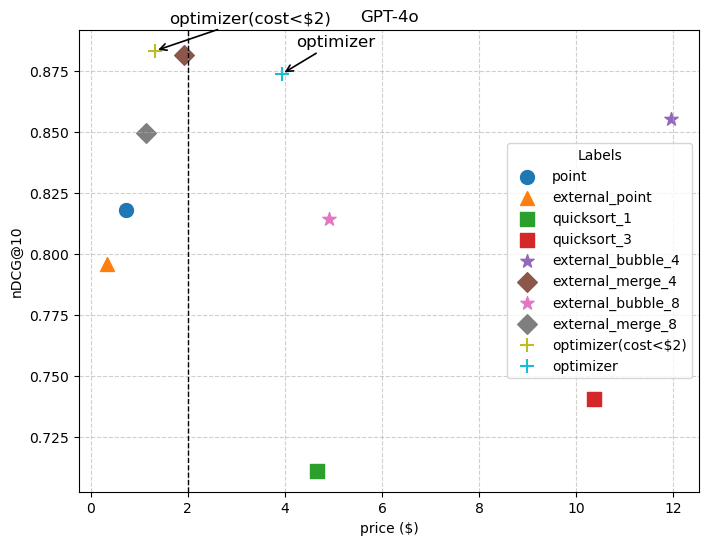

In [9]:
    
# gpt-4o, pointwise Mean nDCG@10: 0.8179801321043914
# tokens: 138896, price: 0.735815
        
# gpt-4o, extrernal pointwise Mean nDCG@10: 0.7961831338376755
# tokens: 70172, price: 0.34259
        
# gpt-4o, quick_sort Mean nDCG@10: 0.7112178492662687
# tokens: 885823, price: 4.662287       
        
# gpt-4o, quick_sort with vote=3 Mean nDCG@10: 0.7407770600993757
# tokens: 1971594, price: 10.37553
        
        
# gpt-4o, external_bubble_sort Mean nDCG@10: 0.8553180888497447
# tokens: 2414336, price: 11.95043
        
# gpt-4o, external_merge_sort Mean nDCG@10: 0.8818374277553904
# tokens: 385572, price: 1.916895
        
# gpt-4o, external_bubble_sort Mean nDCG@10: 0.8144520062915315
# tokens: 948928, price: 4.912
      
# gpt-4o, external_merge_sort Mean nDCG@10: 0.8497489412538956
# tokens: 225835, price: 1.145965
        
    



kendalltau = [0.8179801321043914, 0.7961831338376755,
              0.7112178492662687, 0.7407770600993757,
              0.8553180888497447, 0.8818374277553904,
              0.8144520062915315, 0.8497489412538956
             ]

tokens = [138896, 70172,
          885823, 1971594,
          2414336, 385572,
          948928, 225835
         ]
prices = [0.735815, 0.34259,
          4.662287, 10.37553,
          11.95043, 1.916895,
          4.912, 1.145965
         ]
tokens = [t/(4.0) for t in tokens]
prices = [p for p in prices]

dot_labels = ["point", "external_point",\
              "quicksort_1", "quicksort_3",\
              "external_bubble_4", "external_merge_4",\
              "external_bubble_8", "external_merge_8"
             ]
markers = ['o', '^',\
           's', 's',
           '*', 'D',
           '*', 'D'
          ] 


            
# Create scatter plot
plt.figure(figsize=(8, 6))

for x, y, label, m in zip(prices, kendalltau, dot_labels, markers):
    plt.scatter(x, y, s=100, marker=m, label=label)


# gpt-4o, optimizer 2 output nDCG@10: 0.883454489816776
# tokens: 267256, price: 1.333713

# gpt-4o, optimizer 500 output nDCG@10: 0.8739838856013711
# tokens: 790998, price: 3.942263
        
        
plt.scatter(1.333713, 0.883454489816776, s=100, marker='+', label='optimizer(cost<$2)')
plt.annotate(
    'optimizer(cost<$2)',
    xy=(1.333713, 0.883454489816776),
    xytext=(10, 20),                # offset in *pixels*
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', lw=1.2),
    fontsize=12,
)
plt.axvline(x=2, color='black', linestyle='--', linewidth=1)


plt.scatter(3.942263, 0.8739838856013711, s=100, marker='+', label='optimizer')
plt.annotate(
    'optimizer',
    xy=(3.942263, 0.8739838856013711),
    xytext=(10, 20),                # offset in *pixels*
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', lw=1.2),
    fontsize=12,
)


plt.legend(title="Labels")


# Axis labels and title
plt.xlabel("price ($)")
plt.ylabel("nDCG@10")
plt.title("GPT-4o")

# Show grid and plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


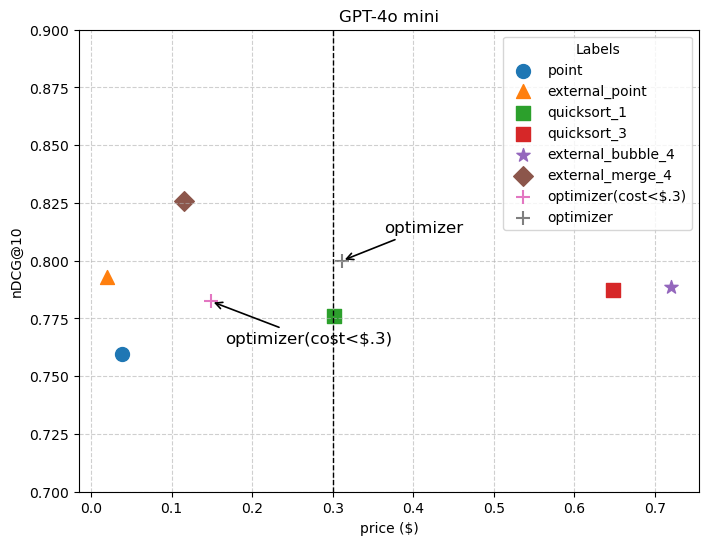

In [16]:
# gpt-4o-mini, pointwise Mean nDCG@10: 0.7594540634215965
# tokens: 130318, price: 0.039002

# gpt-4o-mini, extrernal pointwise Mean nDCG@10: 0.7927725449816558
# tokens: 65657, price: 0.020235
        
# gpt-4o-mini, quick_sort Mean nDCG@10: 0.775987894344237
# tokens: 1031367, price: 0.301329
        
# gpt-4o-mini, quick_sort with vote=3 Mean nDCG@10: 0.7873329340781983
# tokens: 2225452, price: 0.647606

# gpt-4o-mini, external_bubble_sort Mean nDCG@10: 0.788738047604624
# tokens: 2415208, price: 0.719868

# gpt-4o-mini, external_merge_sort Mean nDCG@10: 0.8259361658728819
# tokens: 388780, price: 0.115462


# gpt-4o-mini, optimizer output nDCG@10: 0.793972823799963
# tokens: 67044, price: 0.020486
        
    

kendalltau = [0.7594540634215965, 0.7927725449816558,
              0.775987894344237, 0.7873329340781983,
              0.788738047604624, 0.8259361658728819
             ]
tokens = [130318, 65657,
          1031367, 2225452,
          2415208, 388780
         ]

prices = [0.039002, 0.020235,
          0.301329, 0.647606,
          0.719868, 0.115462
         ]

tokens = [t/(4.0) for t in tokens]
prices = [p for p in prices]


dot_labels = ["point", "external_point",
              "quicksort_1", "quicksort_3",
              "external_bubble_4", "external_merge_4"
             ]
markers = ['o', '^',
           's', 's',
           '*', 'D'
          ] 


            
# Create scatter plot
plt.figure(figsize=(8, 6))

for x, y, label, m in zip(prices, kendalltau, dot_labels, markers):
    plt.scatter(x, y, s=100, marker=m, label=label)


# gpt-4o-mini, optimizer 0.3 output nDCG@10: 0.7823817921962923
# tokens: 502104, price: 0.149056
        
# gpt-4o-mini, optimizer 100 output nDCG@10: 0.8000397116334714
# tokens: 1038748, price: 0.311774

        
plt.scatter(0.149056, 0.7823817921962923, s=100, marker='+', label='optimizer(cost<$.3)')
plt.annotate(
    'optimizer(cost<$.3)',
    xy=(0.149056, 0.7823817921962923),
    xytext=(10, -30),                # offset in *pixels*
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', lw=1.2),
    fontsize=12,
)
plt.axvline(x=0.3, color='black', linestyle='--', linewidth=1)

plt.scatter(0.311774, 0.8000397116334714, s=100, marker='+', label='optimizer')
plt.annotate(
    'optimizer',
    xy=(0.311774, 0.8000397116334714),
    xytext=(30, 20),                # offset in *pixels*
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', lw=1.2),
    fontsize=12,
)


plt.ylim(.7, .9)

plt.legend(title="Labels")


# Axis labels and title
plt.xlabel("price ($)")
plt.ylabel("nDCG@10")
plt.title("GPT-4o mini")

# Show grid and plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()